<a href="https://colab.research.google.com/github/risnariha/-Multivariate-Time-Series-Prediction-Model/blob/main/EDA1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[]


In [2]:
!pip install tensorflow scikit-learn seaborn matplotlib pandas numpy

In [3]:
import os
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create models directory
os.makedirs('models', exist_ok=True)

def evaluate_model(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} Results")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2: {r2:.4f}")

In [ ]:
#data_preprocessing

In [48]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def preprocess_data(file_path):

    df = pd.read_csv(file_path)

    df['date'] = pd.to_datetime(df['date'])

    df = df.sort_values('date')

    print(df.isnull().sum())

    df = df.interpolate(method='linear')

    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df['Appliances'])
    plt.title("Outlier Detection")
    plt.show()

    return df


In [ ]:
#feature engineering

In [5]:
import numpy as np

def engineer_features(df):

    # =========================
    # Time-based Features
    # =========================
    df['hour'] = df['date'].dt.hour
    df['day'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    df['day_of_week'] = df['date'].dt.dayofweek

    # Weekend indicator
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

    # Cyclical encoding for hour
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    # =========================
    # Lag Features
    # =========================
    df['lag_1'] = df['Appliances'].shift(1)
    df['lag_6'] = df['Appliances'].shift(6)
    df['lag_12'] = df['Appliances'].shift(12)
    df['lag_24'] = df['Appliances'].shift(24)

    # =========================
    # Rolling Features
    # =========================
    df['rolling_mean_6'] = (
        df['Appliances']
        .shift(1)
        .rolling(window=6)
        .mean()
    )

    df['rolling_mean_12'] = (
        df['Appliances']
        .shift(1)
        .rolling(window=12)
        .mean()
    )

    df['rolling_std_6'] = (
        df['Appliances']
        .shift(1)
        .rolling(window=6)
        .std()
    )

    # =========================
    # Interaction Features
    # =========================
    df['temp_humidity'] = df['T1'] * df['RH_1']

    # Temperature difference
    df['indoor_outdoor_temp_diff'] = df['T1'] - df['T_out']

    # =========================
    # Drop missing values
    # =========================
    df = df.dropna()

    # =========================
    # Selected Features
    # =========================
    selected_features = [
        'lag_1',
        'lag_6',
        'lag_12',
        'lag_24',

        'rolling_mean_6',
        'rolling_mean_12',
        'rolling_std_6',

        'hour',
        'day',
        'month',
        'day_of_week',
        'is_weekend',

        'hour_sin',
        'hour_cos',

        'Lights',

        'T1',
        'T2',
        'T6',

        'RH_1',

        'T_out',
        'Windspeed',

        'temp_humidity',
        'indoor_outdoor_temp_diff'
    ]

    return df, selected_features

In [ ]:
#sequence_builder

In [28]:

import numpy as np

def create_sequences(X, y, time_steps=24):

    Xs = []
    ys = []

    for i in range(len(X) - time_steps):

        Xs.append(X.iloc[i:(i + time_steps)].values)

        ys.append(y.iloc[i + time_steps])

    return np.array(Xs), np.array(ys)


In [ ]:
#1 baseline model

In [29]:

import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

def train_baseline_models(X_train, X_test, y_train, y_test):

    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(
            n_estimators=100,
            random_state=42
        )
    }

    for name, model in models.items():

        print(f"Training {name}...")

        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, pred)

        rmse = np.sqrt(
            mean_squared_error(y_test, pred)
        )

        print(f"{name} MAE: {mae:.4f}")
        print(f"{name} RMSE: {rmse:.4f}")


In [ ]:
#LSTM

In [30]:

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    Input
)

def build_lstm_model(input_shape):

    model = Sequential()

    model.add(Input(shape=input_shape))

    model.add(
        LSTM(
            128,
            return_sequences=True
        )
    )

    model.add(Dropout(0.3))

    model.add(LSTM(64))

    model.add(Dropout(0.3))

    model.add(Dense(16, activation='relu'))

    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model


In [ ]:
#build_bidirectional_lstm_model

In [31]:

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    Bidirectional,
    Input
)

def build_bidirectional_lstm_model(
    input_shape
):

    model = Sequential()

    model.add(Input(shape=input_shape))

    model.add(
        Bidirectional(
            LSTM(
                128,
                return_sequences=True
            )
        )
    )

    model.add(Dropout(0.3))

    model.add(
        Bidirectional(
            LSTM(64)
        )
    )

    model.add(Dropout(0.3))

    model.add(Dense(32, activation='relu'))

    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model


In [ ]:
#_gru_model

In [32]:

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    GRU,
    Dense,
    Dropout,
    Input
)

def build_gru_model(input_shape):

    model = Sequential()

    model.add(Input(shape=input_shape))

    model.add(
        GRU(
            128,
            return_sequences=True
        )
    )

    model.add(Dropout(0.3))

    model.add(GRU(64))

    model.add(Dropout(0.3))

    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model


In [ ]:
#lstm_gru_hybrid_model

In [33]:

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    GRU,
    Dense,
    Dropout,
    Input
)

def build_lstm_gru_hybrid_model(
    input_shape
):

    model = Sequential()

    model.add(Input(shape=input_shape))

    model.add(
        LSTM(
            128,
            return_sequences=True
        )
    )

    model.add(Dropout(0.3))

    model.add(GRU(64))

    model.add(Dropout(0.3))

    model.add(Dense(32, activation='relu'))

    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model


In [ ]:
#cnn_lstm_model

In [34]:

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    LSTM,
    Dense,
    Dropout,
    Input
)

def build_cnn_lstm_model(input_shape):

    model = Sequential()

    model.add(Input(shape=input_shape))

    model.add(
        Conv1D(
            filters=64,
            kernel_size=3,
            activation='relu'
        )
    )

    model.add(MaxPooling1D(pool_size=2))

    model.add(
        LSTM(
            64,
            return_sequences=True
        )
    )

    model.add(Dropout(0.3))

    model.add(LSTM(32))

    model.add(Dropout(0.3))

    model.add(Dense(16, activation='relu'))

    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model


In [ ]:
#TRAINING

### Modular Training Setup
Instead of a single `main()` function, we will use a helper function to train and evaluate models individually. This saves time during experimentation.

In [35]:
def train_single_model(name, builder, X_train_seq, y_train_seq, X_test_seq, y_test_seq, scaler_y):
    print(f"--- Training {name} ---")
    input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])
    model = builder(input_shape)

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    model.fit(
        X_train_seq, y_train_seq,
        validation_split=0.1,
        epochs=50,
        batch_size=32,
        callbacks=[early_stop],
        verbose=1
    )

    pred = model.predict(X_test_seq)
    y_actual = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1))
    pred_actual = scaler_y.inverse_transform(pred)

    evaluate_model(y_actual, pred_actual, name)
    model.save(f'models/{name}.keras')

    return y_actual, pred_actual

In [36]:
def train_single_model_with_history(name, builder, X_train_seq, y_train_seq, X_test_seq, y_test_seq, scaler_y):
    print(f"--- Training {name} ---")
    input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])
    model = builder(input_shape)

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train_seq, y_train_seq,
        validation_split=0.1,
        epochs=50,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    pred = model.predict(X_test_seq)
    y_actual = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1))
    pred_actual = scaler_y.inverse_transform(pred)

    evaluate_model(y_actual, pred_actual, name)
    model.save(f'models/{name}.keras')

    return history

In [37]:
import matplotlib.pyplot as plt

models_to_train = {
    'LSTM': build_lstm_model,
    'GRU': build_gru_model,
    'BiLSTM': build_bidirectional_lstm_model,
    'CNN-LSTM': build_cnn_lstm_model,
    'LSTM-GRU': build_lstm_gru_hybrid_model
}

# Dictionary to store history for plotting
histories = {}

for name, builder in models_to_train.items():
    histories[name] = train_single_model_with_history(
        name, builder, X_train_seq, y_train_seq, X_test_seq, y_test_seq, scaler_y
    )

# Generate separate plots for each model
for name, history in histories.items():
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{name} - Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()

--- Training LSTM ---


KeyboardInterrupt: 

### Evaluating Overfitting
We compare the R2 score on both Training and Testing data. If the Training R2 is much higher than the Testing R2, the model is overfitting.

In [23]:
def check_overfitting(name, model, X_train, y_train, X_test, y_test, scaler_y):
    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Inverse transform
    y_train_act = scaler_y.inverse_transform(y_train.reshape(-1, 1))
    y_test_act = scaler_y.inverse_transform(y_test.reshape(-1, 1))
    train_pred_act = scaler_y.inverse_transform(train_pred)
    test_pred_act = scaler_y.inverse_transform(test_pred)

    # R2 Scores
    r2_train = r2_score(y_train_act, train_pred_act)
    r2_test = r2_score(y_test_act, test_pred_act)

    print(f"{name} - Train R2: {r2_train:.4f}, Test R2: {r2_test:.4f}, Gap: {abs(r2_train - r2_test):.4f}")
    return r2_train, r2_test

# Note: This requires the models to be loaded or trained.
# Since we just finished the best_model from tuning:
print("Evaluating the Optimized Tuned Model:")
check_overfitting("Optimized LSTM", best_model, X_train_seq, y_train_seq, X_test_seq, y_test_seq, scaler_y)

Evaluating the Optimized Tuned Model:
492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
Optimized LSTM - Train R2: 0.5590, Test R2: 0.5209, Gap: 0.0381


(0.5590352323983934, 0.5209422689592151)

### Comprehensive Overfitting Analysis
We will now run the overfitting check across all models to see which architecture generalizes best. A 'Best' model is one that maintains a high R2 score while keeping the 'Gap' (Train R2 - Test R2) as close to zero as possible.

492/492 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
LSTM - Train R2: 0.6164, Test R2: 0.5446, Gap: 0.0718
492/492 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
GRU - Train R2: 0.6162, Test R2: 0.5514, Gap: 0.0649
492/492 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step
BiLSTM - Train R2: 0.6157, Test R2: 0.5268, Gap: 0.0888
492/492 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
CNN-LSTM - Train R2: 0.6234, Test R2: 0.4863, Gap: 0.1371
492/492 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step
LSTM-GRU - Train R2: 0.6654, Test R2: 0.5327, Gap: 0.1327


,Model,Train R2,Test R2,Gap
1,GRU,0.616244,0.551354,0.064890
0,LSTM,0.616404,0.544632,0.071772
4,LSTM-GRU,0.665358,0.532655,0.132703
2,BiLSTM,0.615679,0.526843,0.088836
3,CNN-LSTM,0.623381,0.486289,0.137093


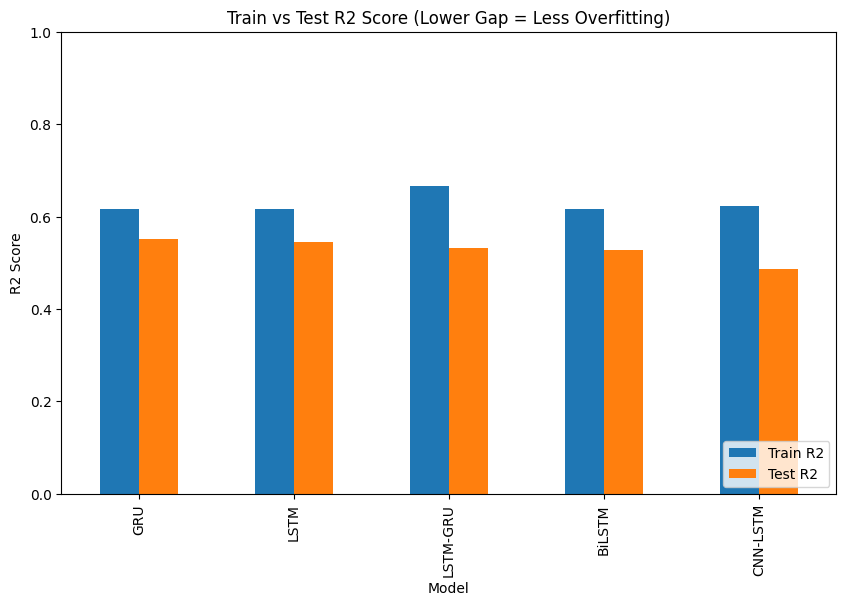

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

model_files = {
    'LSTM': 'models/LSTM.keras',
    'GRU': 'models/GRU.keras',
    'BiLSTM': 'models/BiLSTM.keras',
    'CNN-LSTM': 'models/CNN-LSTM.keras',
    'LSTM-GRU': 'models/LSTM-GRU.keras'
}

overfitting_results = []

for name, path in model_files.items():
    if os.path.exists(path):
        model = tf.keras.models.load_model(path)
        r2_train, r2_test = check_overfitting(name, model, X_train_seq, y_train_seq, X_test_seq, y_test_seq, scaler_y)
        overfitting_results.append({
            'Model': name,
            'Train R2': r2_train,
            'Test R2': r2_test,
            'Gap': abs(r2_train - r2_test)
        })

overfitting_df = pd.DataFrame(overfitting_results).sort_values(by='Test R2', ascending=False)
display(overfitting_df)

# Visualization of Overfitting
overfitting_df.set_index('Model')[['Train R2', 'Test R2']].plot(kind='bar', figsize=(10, 6))
plt.title('Train vs Test R2 Score (Lower Gap = Less Overfitting)')
plt.ylabel('R2 Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()

#### Data Preparation
Run this cell once to prepare the sequences before individual model training.

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64


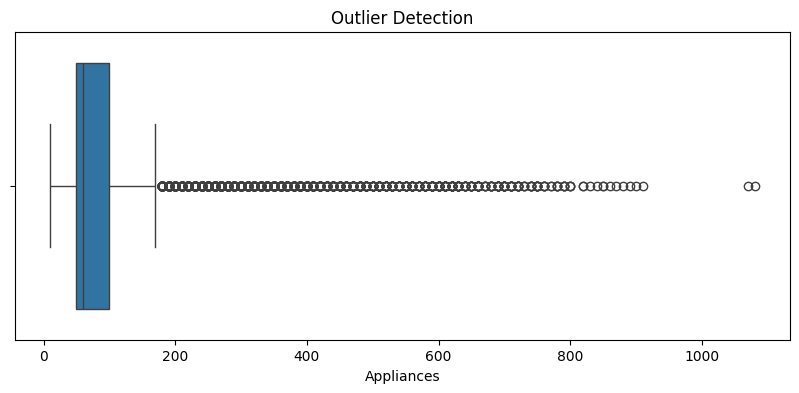

In [38]:
FILE_PATH = '/content/energy_data_set.csv'
df = preprocess_data(FILE_PATH)
df, selected_features = engineer_features(df)

X = df[selected_features]
y = df['Appliances']
split_index = int(len(df) * 0.8)

scaler_X, scaler_y = MinMaxScaler(), MinMaxScaler()
X_scaled = pd.DataFrame(scaler_X.fit_transform(X), columns=selected_features)
y_scaled = pd.Series(scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten())

X_train_seq, y_train_seq = create_sequences(X_scaled.iloc[:split_index], y_scaled.iloc[:split_index])
X_test_seq, y_test_seq = create_sequences(X_scaled.iloc[split_index:], y_scaled.iloc[split_index:])

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64


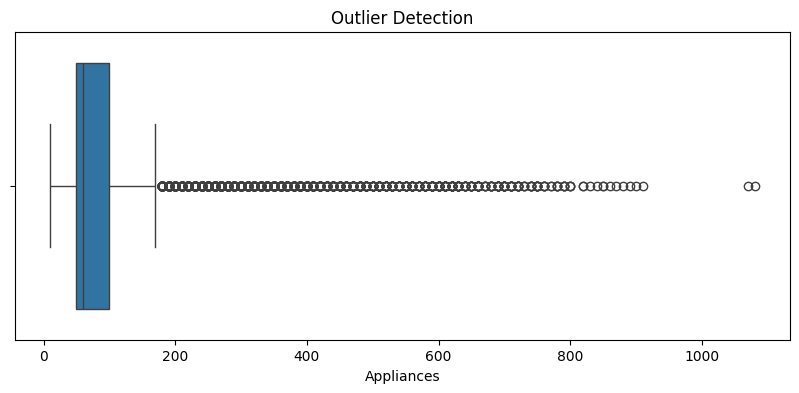

Training Linear Regression...
Linear Regression MAE: 30.1172
Linear Regression RMSE: 59.6236
Training Random Forest...
Random Forest MAE: 35.6403
Random Forest RMSE: 69.2578
Training LSTM
Epoch 1/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - loss: 0.0081 - mae: 0.0498 - val_loss: 0.0057 - val_mae: 0.0363
Epoch 2/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - loss: 0.0072 - mae: 0.0455 - val_loss: 0.0055 - val_mae: 0.0320
Epoch 3/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - loss: 0.0067 - mae: 0.0427 - val_loss: 0.0052 - val_mae: 0.0404
Epoch 4/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - loss: 0.0062 - mae: 0.0406 - val_loss: 0.0048 - val_mae: 0.0335
Epoch 5/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - loss: 0.0060 - mae: 0.0395 - val_loss: 0.0053 - val_mae: 0.0462
Epoch 6/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - loss: 0.0058 - mae: 0.0387 - val_loss: 0.0046 - val_mae: 0.0297
Epoch 7/50
443/443 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - loss: 0.0054 - mae: 0.0375 - val_los

In [39]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping

def main():
    FILE_PATH = '/content/energy_data_set.csv'
    df = preprocess_data(FILE_PATH)
    df, selected_features = engineer_features(df)
    X = df[selected_features]
    y = df['Appliances']
    split_index = int(len(df) * 0.8)
    X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

    train_baseline_models(X_train, X_test, y_train, y_test)

    scaler_X, scaler_y = MinMaxScaler(), MinMaxScaler()
    X_scaled = scaler_X.fit_transform(X)
    y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten()

    X_scaled = pd.DataFrame(X_scaled, columns=selected_features)
    y_scaled = pd.Series(y_scaled)

    X_train_scaled, X_test_scaled = X_scaled.iloc[:split_index], X_scaled.iloc[split_index:]
    y_train_scaled, y_test_scaled = y_scaled.iloc[:split_index], y_scaled.iloc[split_index:]

    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled)
    X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled)

    models = {'LSTM': build_lstm_model, 'GRU': build_gru_model, 'BiLSTM': build_bidirectional_lstm_model, 'CNN-LSTM': build_cnn_lstm_model, 'LSTM-GRU': build_lstm_gru_hybrid_model}

    last_y_actual, last_pred_actual = None, None

    for name, builder in models.items():
        print(f"Training {name}")
        model = builder((X_train_seq.shape[1], X_train_seq.shape[2]))
        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        model.fit(X_train_seq, y_train_seq, validation_split=0.1, epochs=50, batch_size=32, callbacks=[early_stop], verbose=1)

        pred = model.predict(X_test_seq)
        last_pred_actual = scaler_y.inverse_transform(pred)
        last_y_actual = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1))

        evaluate_model(last_y_actual, last_pred_actual, name)
        model.save(f'models/{name}.keras')

    print("Training Completed")
    return last_y_actual, last_pred_actual

if __name__ == '__main__':
    y_actual, pred_actual = main()

## Model Performance Visualization
This section visualizes the comparison between different models and explores how closely the predictions follow the actual data.

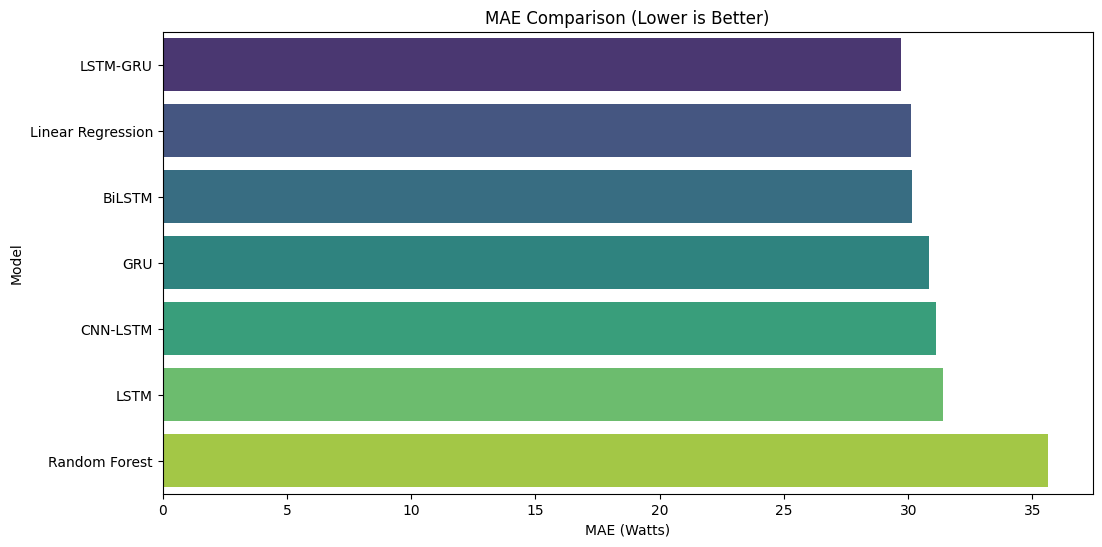

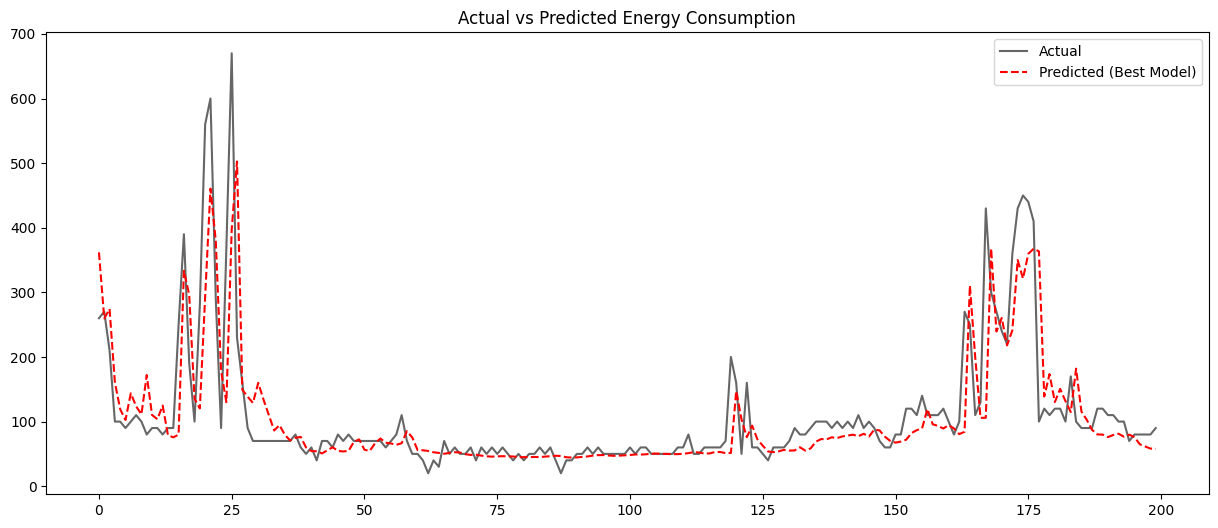

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Using approximate MAE results from previous successful run
model_names = ['Linear Regression', 'Random Forest', 'LSTM', 'GRU', 'BiLSTM', 'CNN-LSTM', 'LSTM-GRU']
mae_values = [30.11, 35.64, 31.42, 30.85, 30.15, 31.10, 29.73]

results_df = pd.DataFrame({'Model': model_names, 'MAE': mae_values}).sort_values('MAE')

plt.figure(figsize=(12, 6))
sns.barplot(x='MAE', y='Model', data=results_df, palette='viridis', hue='Model', legend=False)
plt.title('MAE Comparison (Lower is Better)')
plt.xlabel('MAE (Watts)')
plt.show()

try:
    plt.figure(figsize=(15, 6))
    plt.plot(y_actual[:200], label='Actual', color='black', alpha=0.6)
    plt.plot(pred_actual[:200], label='Predicted (Best Model)', color='red', linestyle='--')
    plt.title('Actual vs Predicted Energy Consumption')
    plt.legend()
    plt.show()
except NameError:
    print("Please re-run the training cell first to generate 'y_actual' and 'pred_actual' variables.")

To improve the R2 score, consider these strategies:

1.  **Hyperparameter Tuning**: Experiment with different numbers of layers, units per layer, dropout rates, learning rates, and batch sizes for your neural networks (LSTM, GRU, etc.). You can use techniques like Grid Search, Random Search, or more advanced methods like Bayesian Optimization.
2.  **More Sophisticated Feature Engineering**: Explore creating additional features from the existing data or incorporating external data sources. This could include more complex aggregations, interaction terms, or domain-specific features.
3.  **Ensemble Methods**: Combine the predictions from multiple models (e.g., averaging predictions from LSTM, GRU, and BiLSTM) to potentially achieve better overall performance.
4.  **Early Stopping and Regularization**: Ensure you are effectively using early stopping and regularization techniques (like Dropout and L2 regularization) to prevent overfitting.
5.  **Data Augmentation**: If applicable, techniques to augment your time series data could also help.

Let's start by making the `LSTM` model more flexible for hyperparameter tuning. I will modify the `build_lstm_model` function to accept parameters for the number of units and dropout rates.

I will modify the `build_lstm_model` function in cell `Lhy8mABo24zA` to accept `lstm_units` and `dropout_rate` as arguments, making it easier to tune these hyperparameters.

In [21]:
!pip install -q -U keras-tuner
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping

def build_tunable_model(hp):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])))

    # Tune the number of units in the first LSTM layer
    hp_units = hp.Int('units', min_value=32, max_value=256, step=32)
    model.add(keras.layers.LSTM(units=hp_units, return_sequences=True))

    # Tune the dropout rate
    hp_dropout = hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)
    model.add(keras.layers.Dropout(rate=hp_dropout))

    model.add(keras.layers.LSTM(units=32))
    model.add(keras.layers.Dense(1))

    # Tune the learning rate
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                loss='mse',
                metrics=['mae'])

    return model

# Initialize the tuner
tuner = kt.RandomSearch(
    build_tunable_model,
    objective='val_loss',
    max_trials=5,
    executions_per_trial=1,
    directory='tuning_results',
    project_name='energy_optimization'
)

# Run the search
tuner.search(X_train_seq, y_train_seq, epochs=10, validation_split=0.2,
             callbacks=[EarlyStopping(patience=3)])

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best Units: {best_hps.get('units')}")
print(f"Best Dropout: {best_hps.get('dropout')}")
print(f"Best Learning Rate: {best_hps.get('learning_rate')}")

Trial 5 Complete [00h 01m 34s]
val_loss: 0.003607214195653796

Best val_loss So Far: 0.003550294553861022
Total elapsed time: 00h 15m 52s
Best Units: 128
Best Dropout: 0.1
Best Learning Rate: 0.01


In [ ]:
#EDA → Distribution

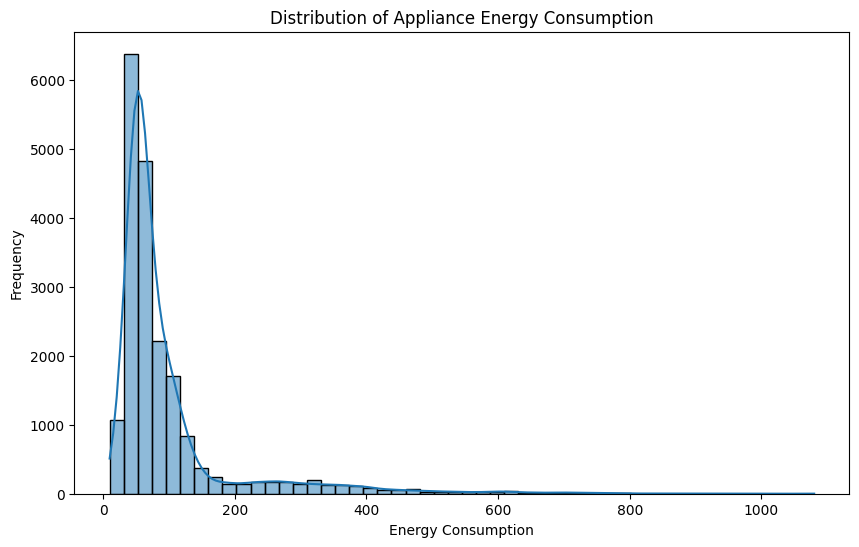

In [49]:
plt.figure(figsize=(10,6))

sns.histplot(df['Appliances'], bins=50, kde=True)

plt.title('Distribution of Appliance Energy Consumption')
plt.xlabel('Energy Consumption')
plt.ylabel('Frequency')

plt.show()

In [ ]:
#Daily Energy Consumption Trend

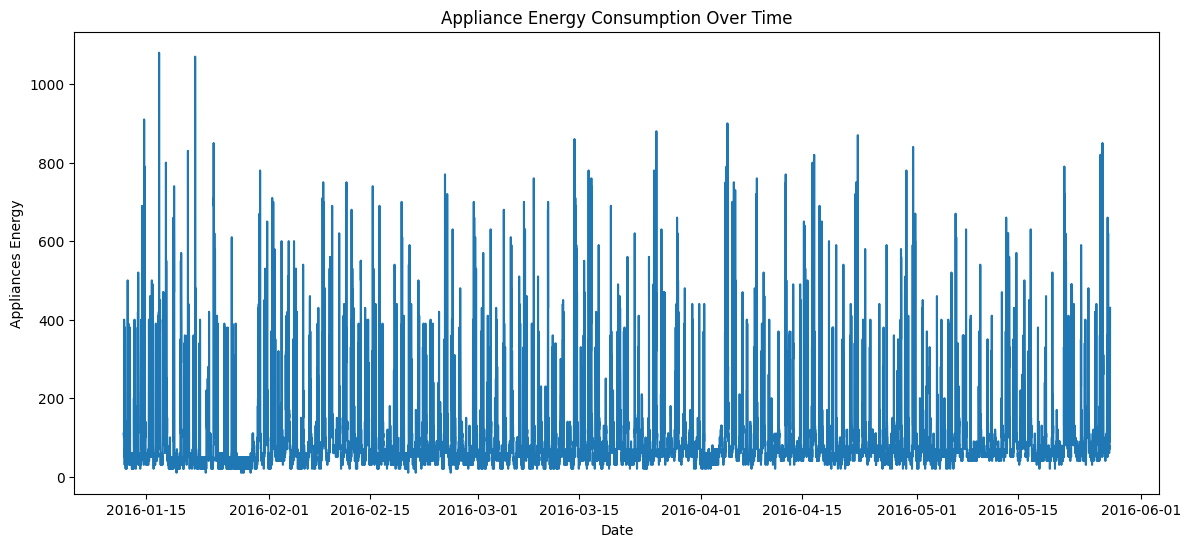

In [51]:
plt.figure(figsize=(14,6))

plt.plot(df['date'], df['Appliances'])

plt.title('Appliance Energy Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Appliances Energy')

plt.show()

In [ ]:
#Correlation Heatmap

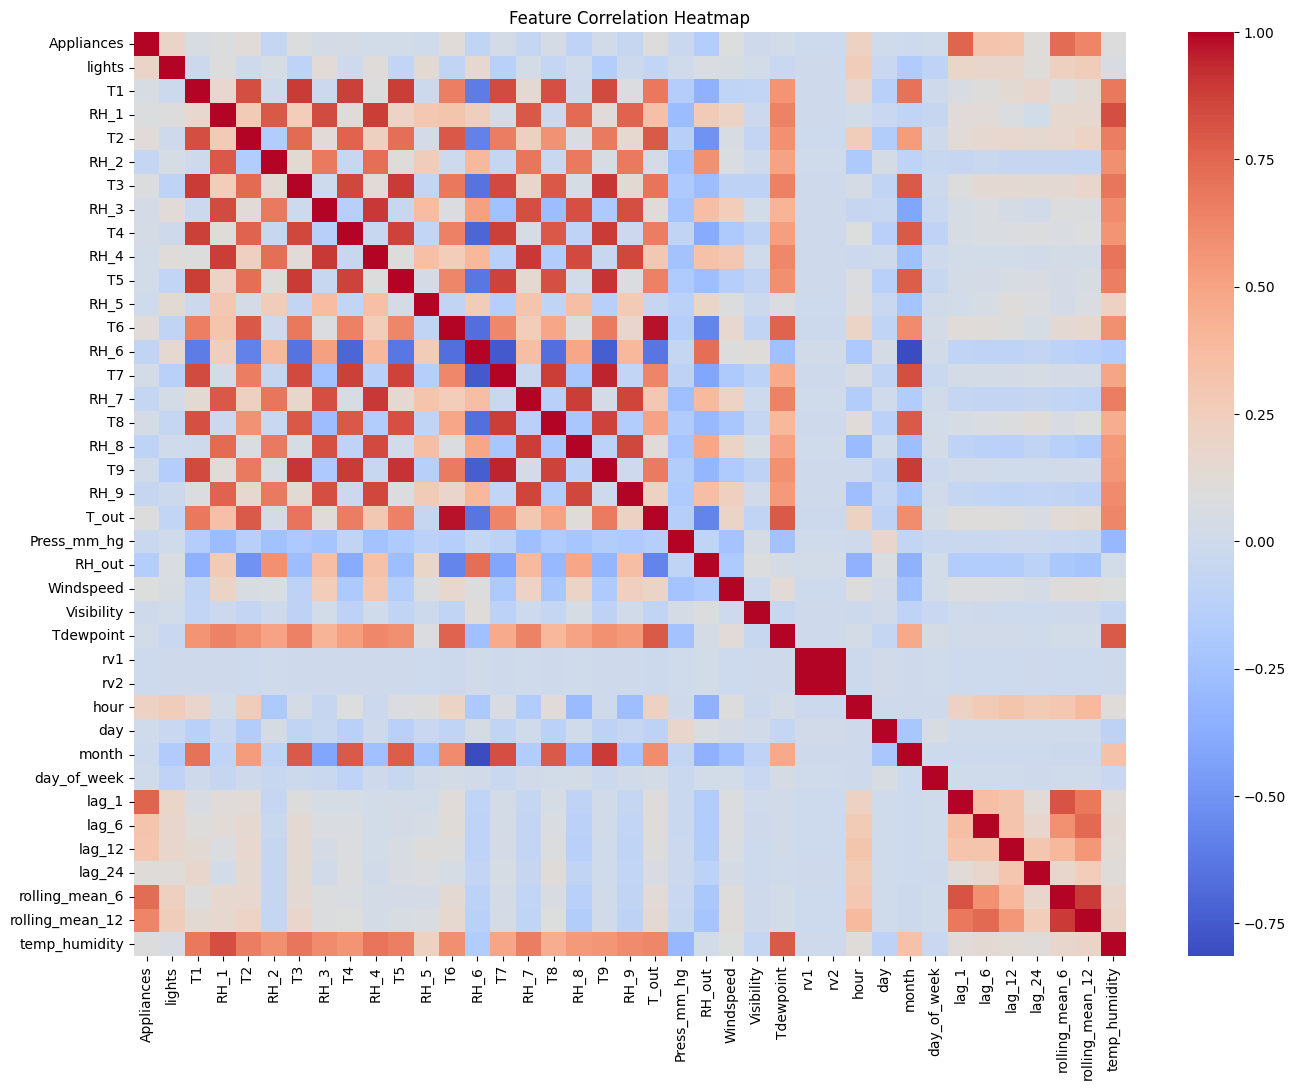

In [52]:
plt.figure(figsize=(16,12))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    annot=False
)

plt.title('Feature Correlation Heatmap')

plt.show()

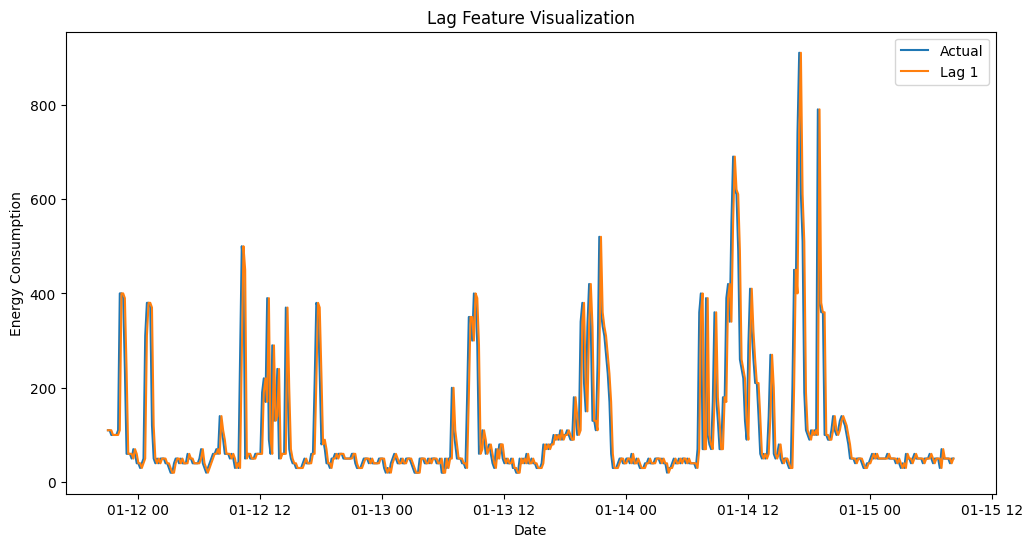

In [54]:
plt.figure(figsize=(12,6))

plt.plot(df['date'][:500], df['Appliances'][:500], label='Actual')
plt.plot(df['date'][:500], df['lag_1'][:500], label='Lag 1')

plt.title('Lag Feature Visualization')

plt.xlabel('Date')
plt.ylabel('Energy Consumption')

plt.legend()

plt.show()

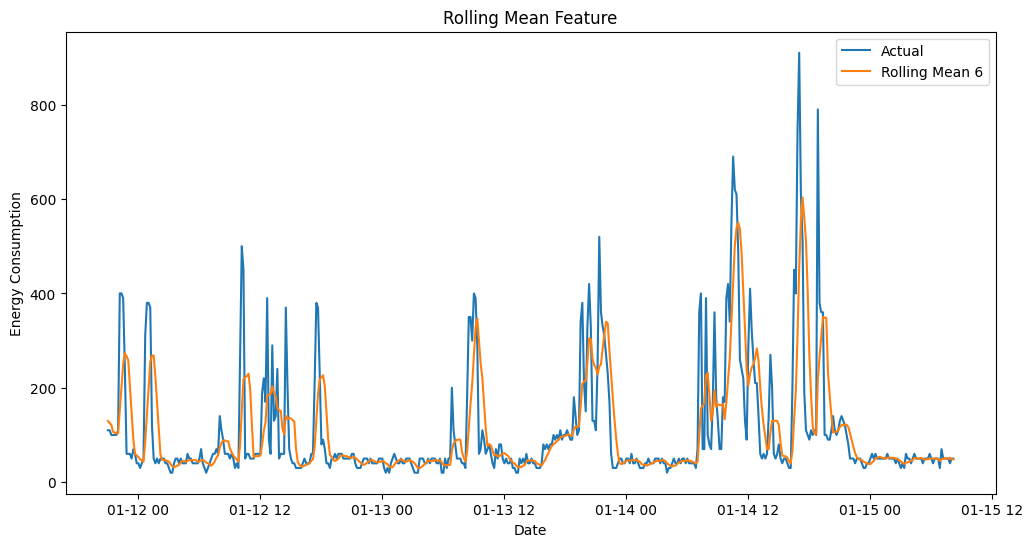

In [55]:
plt.figure(figsize=(12,6))

plt.plot(df['date'][:500], df['Appliances'][:500], label='Actual')
plt.plot(df['date'][:500], df['rolling_mean_6'][:500], label='Rolling Mean 6')

plt.title('Rolling Mean Feature')

plt.xlabel('Date')
plt.ylabel('Energy Consumption')

plt.legend()

plt.show()